<a href="https://colab.research.google.com/github/bhumika0805/CNN-based-Image-Retrival-Search-Engine/blob/main/CIFAR10_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Connects to your Google Drive (it will ask for permission)
drive.mount('/content/drive')

# 2. Path to your zip file in Drive
zip_path = '/content/drive/MyDrive/FMP/imagesearch_dataset.zip'
extract_path = '/content/imagesearch_dataset'

# 3. Unzip the file
print("Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Unzipping complete! You can now run your model code.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping dataset...
Unzipping complete! You can now run your model code.


In [ ]:
import os
import numpy as np
import pickle
from PIL import Image

# CHANGE 1: Import ResNet50 instead of VGG16
from keras.applications.resnet50 import ResNet50, preprocess_input
from keras.models import Model
from keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity

# --- PATH CONFIGURATION ---
# CHANGE 2: We changed this path to match Google Colab instead of a Windows computer
base_path = '/content/imagesearch_dataset'

# CHANGE 3: Renamed the output files so you know these are your ResNet50 results
feature_mapping_path = os.path.join(base_path, 'resnet_feature_mapping.pkl')
img_mapping_path = os.path.join(base_path, 'resnet_img_mapping.pkl')

def load_extractor_model():
    # CHANGE 4: Load ResNet50 instead of VGG16.
    # 'pooling=avg' automatically formats the numbers correctly for image search.
    model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    return model

model = load_extractor_model()
print("ResNet50 Feature extraction model loaded.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Feature extraction model loaded.


In [ ]:
import os
import numpy as np
import pickle
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# --- L2 Normalization Helper ---
def l2_normalize(vector):
    norm = np.linalg.norm(vector)
    if norm == 0:
        return vector
    return vector / norm

def extract_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_data = image.img_to_array(img)
    img_data = np.expand_dims(img_data, axis=0)
    img_data = preprocess_input(img_data)

    features = model.predict(img_data, verbose=0)
    flattened_features = features.flatten()

    normalized_features = l2_normalize(flattened_features)
    return normalized_features

def build_feature_database(data_dir, model):
    all_features = []
    image_paths = []

    print(f"Starting feature extraction in: {data_dir}")

    for root, dirs, files in os.walk(data_dir):
        for file in files:
            # FIX 1: Explicitly ignore Mac hidden junk files
            if file.startswith('._'):
                continue

            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)
                try:
                    features = extract_features(full_path, model)
                    all_features.append(features)
                    image_paths.append(full_path)

                    if len(image_paths) % 100 == 0:
                        print(f"Processed {len(image_paths)} images...")

                except Exception:
                    # FIX 2: If any other image is corrupted, just silently skip it
                    pass

    features_array = np.array(all_features)

    with open(feature_mapping_path, 'wb') as f:
        pickle.dump(features_array, f)
    with open(img_mapping_path, 'wb') as f:
        pickle.dump(image_paths, f)

    return features_array, image_paths

# --- EXECUTION ---
features_db, paths_db = build_feature_database(base_path, model)
print(f"Step 2 Complete: Database built and L2-normalized with {len(paths_db)} images.")

Starting feature extraction in: /content/imagesearch_dataset
Processed 100 images...
Processed 200 images...
Processed 300 images...
Processed 400 images...
Processed 500 images...
Processed 600 images...
Processed 700 images...
Processed 800 images...
Processed 900 images...
Processed 1000 images...
Step 2 Complete: Database built and L2-normalized with 1000 images.


Searching for matches to: /content/imagesearch_dataset/imagesearch_dataset/imagesearch/aeroplane/2008_000716.jpg


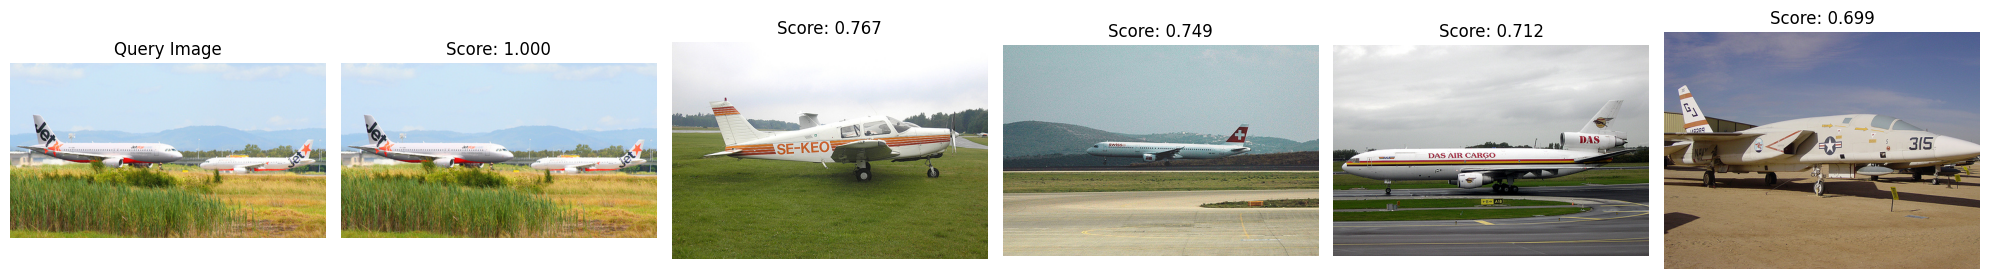

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.metrics.pairwise import cosine_similarity

def perform_search_and_display(query_img_path, features_db, paths_db, model, top_n=5):
    # 1. Extract and normalize features for the query image
    query_features = extract_features(query_img_path, model).reshape(1, -1)

    # 2. Calculate cosine similarity
    similarities = cosine_similarity(query_features, features_db).flatten()

    # 3. Get indices of the top_n results
    closest_indices = similarities.argsort()[-top_n:][::-1]

    # 4. Visualization
    plt.figure(figsize=(20, 10))

    # Display Query Image
    ax = plt.subplot(1, top_n + 1, 1)
    plt.imshow(image.load_img(query_img_path))
    ax.set_title("Query Image")
    ax.axis('off')

    # Display Results
    for i, idx in enumerate(closest_indices):
        ax = plt.subplot(1, top_n + 1, i + 2)
        img = mpimg.imread(paths_db[idx])
        plt.imshow(img)
        ax.set_title(f"Score: {similarities[idx]:.3f}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN THE SEARCH ---
# CHANGE 1: We changed the path so it works in Google Colab!
# This automatically grabs the first image in your database to use as a test.
# query_image = paths_db[0]

# (If you want to test a specific image later, you can replace the line above with your exact Colab path)
query_image = '/content/imagesearch_dataset/imagesearch_dataset/imagesearch/aeroplane/2008_000716.jpg'

if os.path.exists(query_image):
    print(f"Searching for matches to: {query_image}")
    perform_search_and_display(query_image, features_db, paths_db, model)
else:
    print("Please provide a valid path for 'query_image' to see the results.")

In [ ]:
def add_single_image_to_db(new_img_path, model, feature_mapping_path, img_mapping_path):
    # 1. Load existing data
    with open(feature_mapping_path, 'rb') as f:
        features_db = pickle.load(f)
    with open(img_mapping_path, 'rb') as f:
        paths_db = pickle.load(f)

    # 2. Check if image is already in DB to avoid duplicates
    if new_img_path in paths_db:
        print("Image already exists in database.")
        return features_db, paths_db

    # 3. Extract and normalize features for the new image
    new_features = extract_features(new_img_path, model)

    # 4. Append to existing lists/arrays
    updated_features_db = np.vstack([features_db, new_features])
    paths_db.append(new_img_path)

    # 5. Save back to disk
    with open(feature_mapping_path, 'wb') as f:
        pickle.dump(updated_features_db, f)
    with open(img_mapping_path, 'wb') as f:
        pickle.dump(paths_db, f)

    print(f"Added {os.path.basename(new_img_path)} to database. New total: {len(paths_db)}")
    return updated_features_db, paths_db

# --- EXAMPLE USAGE ---
# CHANGE: Updated to a Google Colab path style.
# Keep this commented out (with the #) unless you actually want to upload a new image and test it!
# features_db, paths_db = add_single_image_to_db('/content/my_uploaded_picture.jpg', model, feature_mapping_path, img_mapping_path)

In [ ]:
def load_database(feature_mapping_path, img_mapping_path):
    """Loads the pre-calculated features so you can search instantly."""
    if os.path.exists(feature_mapping_path) and os.path.exists(img_mapping_path):
        with open(feature_mapping_path, 'rb') as f:
            features_db = pickle.load(f)
        with open(img_mapping_path, 'rb') as f:
            paths_db = pickle.load(f)
        print(f"Database loaded successfully: {len(paths_db)} images found.")
        return features_db, paths_db
    else:
        print("Database files not found. Please run Step 2 first.")
        return None, None

# --- HOW TO USE IT STARTING TOMORROW ---
# 1. Load Model
# model = load_extractor_model()

# 2. Load the Saved Data (No need to wait for extraction again!)
# features_db, paths_db = load_database(feature_mapping_path, img_mapping_path)

# 3. Search!
# if features_db is not None:
#    perform_search_and_display(query_image, features_db, paths_db, model)

In [ ]:
def get_label_from_path(path):
    # This assumes your path is like: .../imagesearch/aeroplane/image1.jpg
    # It takes the folder name immediately preceding the filename
    return os.path.basename(os.path.dirname(path))

# Create a list of labels for your entire database
labels_db = [get_label_from_path(p) for p in paths_db]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_retrieval(query_img_path, features_db, paths_db, labels_db, model, k=10):
    query_label = get_label_from_path(query_img_path)
    query_features = extract_features(query_img_path, model).reshape(1, -1)

    # Calculate similarities
    similarities = cosine_similarity(query_features, features_db).flatten()

    # Get top K indices
    top_k_indices = similarities.argsort()[-k:][::-1]

    # Determine True Positives: Does the result label match the query label?
    # 1 if it matches (Relevant), 0 if it doesn't (Irrelevant)
    results_relevance = [1 if labels_db[i] == query_label else 0 for i in top_k_indices]

    # --- METRICS CALCULATION ---
    # Precision@K: How many of the top K results are relevant?
    precision_at_k = sum(results_relevance) / k

    # Recall@K: How many of the TOTAL relevant images in the DB did we find in top K?
    total_relevant_in_db = labels_db.count(query_label)
    recall_at_k = sum(results_relevance) / total_relevant_in_db

    # F1 Score@K
    if (precision_at_k + recall_at_k) > 0:
        f1_at_k = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)
    else:
        f1_at_k = 0

    return {
        "precision": precision_at_k,
        "recall": recall_at_k,
        "f1": f1_at_k,
        "relevance_map": results_relevance
    }

In [ ]:
def calculate_ap(relevance_map):
    """Calculates Average Precision for a single query's results."""
    count_relevant = 0
    precision_sum = 0
    for i, is_relevant in enumerate(relevance_map):
        if is_relevant:
            count_relevant += 1
            precision_at_i = count_relevant / (i + 1)
            precision_sum += precision_at_i

    return precision_sum / count_relevant if count_relevant > 0 else 0

# To get mAP, you would run this for multiple queries and average the AP scores.

In [ ]:
import random

# Pick 50 random images from your database to act as test queries
test_indices = random.sample(range(len(paths_db)), 50)
all_ap = []

for idx in test_indices:
    query_path = paths_db[idx]
    metrics = evaluate_retrieval(query_path, features_db, paths_db, labels_db, model, k=10)
    ap = calculate_ap(metrics['relevance_map'])
    all_ap.append(ap)

print(f"Mean Average Precision (mAP@10): {np.mean(all_ap):.4f}")

Mean Average Precision (mAP@10): 0.8575


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import random
import numpy as np

def run_full_evaluation(features_db, paths_db, labels_db, model, sample_size=100, k=10):
    precisions = []
    recalls = []
    f1s = []
    aps = []

    # Select random samples to evaluate
    test_indices = random.sample(range(len(paths_db)), min(sample_size, len(paths_db)))

    print(f"Evaluating {len(test_indices)} queries...")

    for idx in test_indices:
        query_path = paths_db[idx]
        metrics = evaluate_retrieval(query_path, features_db, paths_db, labels_db, model, k=k)

        precisions.append(metrics['precision'])
        recalls.append(metrics['recall'])
        f1s.append(metrics['f1'])
        aps.append(calculate_ap(metrics['relevance_map']))

    # Final Averages
    print("\n--- Image Search Engine Performance Report ---")
    print(f"Mean Precision@{k}: {np.mean(precisions):.4f}")
    print(f"Mean Recall@{k}:    {np.mean(recalls):.4f}")
    print(f"Mean F1-Score@{k}:  {np.mean(f1s):.4f}")
    print(f"mAP@{k}:            {np.mean(aps):.4f}")
    print("----------------------------------------------")

# Run the report
run_full_evaluation(features_db, paths_db, labels_db, model)

Evaluating 100 queries...

--- Image Search Engine Performance Report ---
Mean Precision@10: 0.4620
Mean Recall@10:    0.0924
Mean F1-Score@10:  0.1540
mAP@10:            0.8310
----------------------------------------------
